In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import math
import statistics
import matplotlib.pyplot as plt
from sqlalchemy.exc import NoResultFound

In [3]:
from datetime import datetime
from tqdm import tqdm
import random

In [4]:
from dataloader.utils import *
import utils.utils as utils
from feature_selection import *

In [5]:
from database import init_engine, get_session, Winnings

init_engine()
session = get_session()

In [6]:
def calculate_mean_decay_speed(p, ps, time_decay=0.03):
    race_date = p.race.date
    corresponding = [[(race_date - this_p.race.date).days, calculate_speed(this_p)] for this_p in ps]
    data = np.array(corresponding, dtype=np.float32)
    days = data[:, 0]
    speeds = data[:, 1]
    weighting_factor = np.exp(-time_decay * days)
    return np.dot(weighting_factor, speeds) / np.sum(weighting_factor)

def calculate_weighted_mean_speed(p, ps, time_decay=0.03):
    # Create a list of (time_diff, speed) pairs
    race_date = p.race.date
    corresponding = [
        [(race_date - this_p.race.date).days, calculate_speed(this_p)]
        for this_p in ps
    ]

    # Convert to a numpy array for easier manipulation
    data = np.array(corresponding, dtype=np.float32)
    days = data[:, 0]  # Time difference in days
    speeds = data[:, 1]  # Speed values

    # Calculate weights based on exponential decay
    weighting_factor = np.exp(-time_decay * days)

    # Normalize the weights so they sum up to 1
    normalized_weights = weighting_factor / np.sum(weighting_factor)

    # Compute weighted mean of speeds
    weighted_mean_speed = np.dot(normalized_weights, speeds)

    return weighted_mean_speed


In [7]:
def convert_ranking_to_relevance_score(ranking, decay_sharpness=2):
    return 1 / torch.log(ranking + decay_sharpness)


In [8]:
def swap_vector_matrix(vector):
  n = vector.size(0)
  i = torch.arange(n).view(n, 1, 1)
  j = torch.arange(n).view(1, n, 1)

  M = vector.repeat(n, n, 1)
  M[i, j, i], M[i, j, j] = M[i, j, j], M[i, j, i]

  return M


def ndcg(a_score, p_score, k=None):
    if k is None:
        k = a_score.size(0)

    # Ensure p_score is a 3D tensor (batch_size, num_vectors, vector_size)
    if p_score.dim() == 1:
        p_score = p_score.unsqueeze(0).unsqueeze(0)  # Convert to 3D if it's a single matrix

    batch_size, num_vectors, vector_size = p_score.shape

    # Get the top-k indices for each vector in p_score
    _, p_rankings = torch.topk(p_score, k, dim=2)  # Shape: (batch_size, num_vectors, k)

    # Positions for DCG calculation (same for all vectors)
    positions = torch.arange(1, k + 1, dtype=torch.float32, device=a_score.device)  # Shape: (k,)

    # Gather the real scores using p_rankings
    # Expand a_score to match the shape of p_rankings for advanced indexing
    a_score_expanded = a_score.unsqueeze(0).unsqueeze(0)  # Shape: (1, 1, vector_size)
    real_scores = a_score_expanded.expand(batch_size, num_vectors, -1).gather(2, p_rankings)  # Shape: (batch_size, num_vectors, k)

    # Calculate DCG for each vector
    dcg = torch.sum((2 ** real_scores - 1) / torch.log2(positions + 1), dim=2)  # Shape: (batch_size, num_vectors)

    # Calculate IDCG (same for all vectors)
    ideal_scores, _ = torch.sort(a_score, descending=True)
    ideal_scores = ideal_scores[:k]  # Shape: (k,)
    idcg = torch.sum((2 ** ideal_scores - 1) / torch.log2(positions + 1))  # Scalar

    # Compute NDCG for all vectors
    ndcg_scores = dcg / idcg if idcg > 0 else torch.zeros_like(dcg)  # Shape: (batch_size, num_vectors)

    return ndcg_scores


def lambda_rank_loss(p_score, a_score, k=None):
    s_ij = p_score.unsqueeze(1) - p_score.unsqueeze(0)
    a_ij = a_score.unsqueeze(1) - a_score.unsqueeze(0)
    sign = (a_ij > 0).float()

    # old_ndcg = ndcg(a_score, p_score, k=k)
    # swapped_p = swap_vector_matrix(p_score)
    # new_ndcg =  ndcg(a_score, swapped_p, k=k)
    # delta_ndcg = new_ndcg - old_ndcg

    loss = sign * torch.log(torch.sigmoid(s_ij) + 1e-10) + (1 - sign) * torch.log(1 - torch.sigmoid(s_ij) + 1e-10) * torch.abs(a_ij)
    loss = torch.nan_to_num(loss, nan=0)

    equal_mask = (a_ij != 0).float()
    diagonal_mask = torch.ones_like(loss).fill_diagonal_(False)
    loss = loss * equal_mask * diagonal_mask
    return -loss.mean()

In [9]:
def get_mean_std(data_x):
    mean = torch.mean(data_x, dim=0)
    std = torch.std(data_x, dim=0)
    std[std == 0] = 1
    return mean, std


In [10]:
def perform_prediction(model, normalized_x, horse_nums):
    model.eval()
    with torch.no_grad():
        predictions = model(normalized_x)
        predictions = torch.softmax(predictions, dim=0)
    horse_nums = horse_nums.tolist()
    horse_predictions = list(zip(horse_nums, predictions.tolist()))
    horse_predictions.sort(key=lambda x: x[1], reverse=True)

    return horse_predictions[0][0], horse_predictions[1][0]


In [11]:
def group_data(data_x, data_y, test_data, horse_nums, test_h_nums):
    return {
        "data_x": data_x,
        "data_y": data_y,
        "test_data": test_data,
        "horse_nums": horse_nums,
        "test_h_nums": test_h_nums,
    }


def group_results(winner_horses, place_horses, test_winner_horses, test_place_horses):
    return {
        "winner_horses": winner_horses,
        "place_horses": place_horses,
        "test_winner_horses": test_winner_horses,
        "test_place_horses": test_place_horses,
    }


def group_settings(train_keys, cv_keys, train_mean, train_std, epochs, is_lambda_rank):
    return {
        "train_keys": train_keys,
        "cv_keys": cv_keys,
        "train_mean": train_mean,
        "train_std": train_std,
        "epochs": epochs,
        "is_lambda_rank": is_lambda_rank,
    }

In [85]:
def calculate_cost(model, target_keys, data_x, data_y, settings):
    is_lambda_rank = settings["is_lambda_rank"]
    criterion = lambda_rank_loss if is_lambda_rank else nn.MSELoss()
    train_mean = settings["train_mean"]
    train_std = settings["train_std"]
    total_cost = 0
    for key in target_keys:
        this_x = torch.tensor(data_x[key], dtype=torch.float32, device="cuda")
        this_y = torch.tensor(data_y[key], dtype=torch.float32, device="cuda")
        this_y = convert_ranking_to_relevance_score(this_y)

        this_mean = torch.mean(this_x, dim=0)
        this_std = torch.std(this_x, dim=0)
        this_std[this_std == 0] = 1
        normalized_x = (this_x - this_mean) / this_std

        # this_max = torch.max(this_x, dim=0)[0]
        # this_min = torch.min(this_x, dim=0)[0]
        # factor = this_max - this_min
        # factor[factor == 0] = 1
        # normalized_x = (this_x - this_min) / factor

        output = model(normalized_x)
        output = output.flatten()
        this_y = this_y.flatten()
        loss = criterion(output, this_y)

        assert not torch.isnan(normalized_x).any(), "normalized x contains nan"
        try:
            assert not torch.isnan(output).any(), "output contains nan"
        except AssertionError:
            print(output)
            print("=" * 100)
            print(normalized_x)
            print("=" * 100)
            print(model(normalized_x))
            assert False, "output contains nan"
        total_cost += loss.item()

    return total_cost / len(target_keys)


In [13]:
def load_data(size, f, distance=None, train_mode=True):
    if train_mode:
        start_date = datetime(2012, 9, 1)
        end_date = datetime(2022, 9, 1)
    else:
        start_date = datetime(2022, 9, 1)
        end_date = datetime(2024, 9, 1)

    races = session.query(Race).filter(Race.date >= start_date).filter(Race.date < end_date)
    if distance is not None:
        races = races.filter(Race.distance == distance)
    races = races.all()
    all_x = {}
    horse_nums = {}
    all_y = {}
    winner = {}
    place = {}
    for race in tqdm(races, desc="Loading races"):
        ps = get_relevant_ps_from_race(race)
        total = len(utils.remove_unranked_participants(race.participations))
        m = len(ps)
        if total - m >= 3 or m < 5:
            continue

        this_x = np.zeros((m, size), dtype=np.float32)
        this_horse_nums = np.zeros(m, dtype=int)
        this_y = np.zeros((m, 1), dtype=np.float32)

        for i, p in enumerate(ps):
            this_x[i] = f(p)
            this_horse_nums[i] = p.number
            ranking = get_ranking_from_participation(p)
            this_y[i, 0] = ranking

        all_x[race.id] = this_x
        all_y[race.id] = this_y
        horse_nums[race.id] = this_horse_nums

        this_winnings = race.winnings
        for winning in this_winnings:
            if winning.pool == "WIN":
                if race.id not in winner:
                    winner[race.id] = []
                winner[race.id].append(int(winning.combination))
            elif winning.pool == "PLACE":
                if race.id not in place:
                    place[race.id] = []
                place[race.id].append(int(winning.combination))

    no_nan = True
    for key in all_x:
        this_x = all_x[key]
        if np.isnan(this_x).any():
            no_nan = False
            break

    print(f"No nan: {no_nan}")

    return all_x, all_y, horse_nums, winner, place

In [87]:
def test_accuracy(model, data_x, horse_nums, winner_horses, place_horses, settings):
    with torch.no_grad():
        train_mean = settings["train_mean"]
        train_std = settings["train_std"]
        winner_count = 0
        place_count = 0
        q_place_count = 0
        total_count = 0
        for key in data_x:
            this_x = torch.tensor(data_x[key], dtype=torch.float32, device="cuda")

            this_mean = torch.mean(this_x, dim=0)
            this_std = torch.std(this_x, dim=0)
            this_std[this_std == 0] = 1
            normalized_x = (this_x - this_mean) / this_std

            # this_max = torch.max(this_x, dim=0)[0]
            # this_min = torch.min(this_x, dim=0)[0]
            # factor = this_max - this_min
            # factor[factor == 0] = 1
            # normalized_x = (this_x - this_min) / factor

            first, second = perform_prediction(model, normalized_x, horse_nums[key])

            if first in winner_horses[key]:
                winner_count += 1
            if first in place_horses[key]:
                place_count += 1
                if second in place_horses[key]:
                    q_place_count += 1
            total_count += 1

    return winner_count, place_count, q_place_count, total_count

In [15]:
def prepare_training(features_size, data_x):
    train_keys, cv_keys = get_train_cv_split(list(data_x.keys()))

    # get calculate_train_size
    train_size = 0
    for key in train_keys:
        train_size += data_x[key].shape[0]

    train_x = np.zeros((train_size, features_size), dtype=np.float32)
    counter = 0
    for key in train_keys:
        current_x = data_x[key]
        current_m = current_x.shape[0]
        train_x[counter:counter + current_m] = current_x
        counter += current_m

    train_x = torch.tensor(train_x, dtype=torch.float32, device="cuda")
    train_mean, train_std = get_mean_std(train_x)

    return train_mean, train_std, train_keys, cv_keys

In [92]:
def train_model(model, data, results, settings):
    data_x = data["data_x"]
    data_y = data["data_y"]
    test_data = data["test_data"]
    horse_nums = data["horse_nums"]
    test_horse_nums = data["test_h_nums"]
    train_mean = settings["train_mean"]
    train_std = settings["train_std"]
    train_keys = settings["train_keys"]
    cv_keys = settings["cv_keys"]
    epochs = settings["epochs"]
    is_lambda_rank = settings["is_lambda_rank"]

    winner_horses = results["winner_horses"]
    place_horses = results["place_horses"]
    test_winner_horses = results["test_winner_horses"]
    test_place_horses = results["test_place_horses"]

    model.eval()
    initial_train_cost = calculate_cost(model, train_keys, data_x, data_y, settings)
    initial_cv_cost = calculate_cost(model, cv_keys, data_x, data_y, settings)
    print(f"Initial cost: {initial_train_cost}. CV cost: {initial_cv_cost}")

    max_test_accuracy = 0
    max_train_accuracy = 0

    train_hist = []
    cv_hist = []

    criterion = lambda_rank_loss if is_lambda_rank else nn.MSELoss()
    optimizer = model.optimizer()
    for epoch in range(epochs):
        model.train()
        for key in train_keys:
            this_x = torch.tensor(data_x[key], dtype=torch.float32, device="cuda")
            this_y = torch.tensor(data_y[key], dtype=torch.float32, device="cuda")
            this_y = convert_ranking_to_relevance_score(this_y)

            this_mean = torch.mean(this_x, dim=0)
            this_std = torch.std(this_x, dim=0)
            this_std[this_std == 0] = 1
            normalized_x = (this_x - this_mean) / this_std

            # this_max = torch.max(this_x, dim=0)[0]
            # this_min = torch.min(this_x, dim=0)[0]
            # factor = this_max - this_min
            # factor[factor == 0] = 1
            # normalized_x = (this_x - this_min) / factor

            output = model(normalized_x)
            output = output.flatten()
            this_y = this_y.flatten()
            loss = criterion(output, this_y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        model.eval()
        train_cost = calculate_cost(model, train_keys, data_x, data_y, settings)
        cv_cost = calculate_cost(model, cv_keys, data_x, data_y, settings)
        train_hist.append(train_cost)
        cv_hist.append(cv_cost)

        this_train_count = test_accuracy(model, data_x, horse_nums, winner_horses, place_horses, settings)
        this_train_accuracy = this_train_count[0] / this_train_count[3]
        this_test_count = test_accuracy(model, test_data, test_horse_nums, test_winner_horses, test_place_horses, settings)
        this_test_accuracy = this_test_count[0] / this_test_count[3]

        if this_test_accuracy > max_test_accuracy:
            max_test_accuracy = this_test_accuracy
            max_train_accuracy = this_train_accuracy

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1}/{epochs} - train cost = {train_cost:.5f}, cv cost: {cv_cost:.5f}, train accuracy: {this_train_accuracy * 100:.2f}%")

    return  max_train_accuracy, max_test_accuracy, train_hist, cv_hist

In [17]:
def display_accuracy(header, accuracy):
    win_count, place_count, q_place_count, total_count = accuracy
    print(f"======== Stats for {header} ========")
    print(f"Winner accuracy: {win_count / total_count * 100:.2f}%")
    print(f"Place accuracy: {place_count / total_count * 100:.2f}%")
    print(f"Q Place accuracy: {q_place_count / total_count * 100:.2f}%")


def plot_cost_history_graph(train_hist, cv_hist):
    x_axis = list(range(len(train_hist)))
    plt.plot(x_axis, train_hist, label="Training data")
    plt.plot(x_axis, cv_hist, label="Test data")
    plt.legend()
    plt.xlabel("Epoch")
    plt.ylabel("Cost")
    plt.show()


def experiment_features(model, features_size, data, results, epochs, is_lambda_rank):
    data_x = data["data_x"]
    horse_nums = data["horse_nums"]
    winner_horses = results["winner_horses"]
    place_horses = results["place_horses"]
    test_data = data["test_data"]
    test_h_nums = data["test_h_nums"]
    test_winner_horses = results["test_winner_horses"]
    test_place_horses = results["test_place_horses"]

    model = model.to("cuda")
    train_mean, train_std, train_keys, cv_keys = prepare_training(features_size, data_x)
    print(f"Training model on {len(train_keys)} races.")
    settings = group_settings(train_keys, cv_keys, train_mean, train_std, epochs, is_lambda_rank)

    max_train_accuracy, max_test_accuracy, train_hist, cv_hist = train_model(model, data, results, settings)
    plot_cost_history_graph(train_hist, cv_hist)

    data_accuracy = test_accuracy(model, data_x, horse_nums, winner_horses, place_horses, settings)
    test_data_accuracy = test_accuracy(model, test_data, test_h_nums, test_winner_horses, test_place_horses, settings)
    display_accuracy("Train data", data_accuracy)
    display_accuracy("Test data", test_data_accuracy)
    print(f"======== Overall stats ========")
    print(f"Max test WIN accuracy: {max_test_accuracy * 100:.2f}%")
    print(f"Train accuracy then: {max_train_accuracy * 100:.2f}%")

    return max_train_accuracy, max_test_accuracy, train_mean, train_std

In [47]:
class EightFeaturesLambdaRank(nn.Module):
    def __init__(self):
        super(EightFeaturesLambdaRank, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(8, 6),
            nn.ReLU(),
            nn.Linear(6, 1)
        )

    def forward(self, x):
        return self.model(x)

    def optimizer(self):
        return optim.SGD(self.model.parameters(), lr=0.001, momentum=0.9)


def load_eight_features(p):
    latest_horse_p = get_latest_horse_p(p)
    old_ps = get_old_ps(p)
    return np.array([
        p.rating,
        p.rating - latest_horse_p.rating if latest_horse_p.rating is not None else 25,
        p.horse_weight,
        p.gear_weight / (p.gear_weight + p.horse_weight),
        calculate_speed(latest_horse_p),
        calculate_mean_speed(old_ps),
        calculate_mean_decay_speed(p, old_ps),
        latest_horse_p.win_odds
    ], dtype=np.float32)


model = EightFeaturesLambdaRank()
_, _ = experiment_features(model, 8, load_eight_features, distance=1400, epochs=150)

TypeError: experiment_features() got an unexpected keyword argument 'distance'

Loading races: 100%|██████████| 1321/1321 [00:34<00:00, 38.20it/s]


No nan: True


Loading races: 100%|██████████| 265/265 [00:05<00:00, 44.35it/s]


No nan: True
Training model on 1112 races.
Initial cost: 0.3976970194644636. CV cost: 0.39586865541435057
Epoch 10/150 - train cost = 0.36913, cv cost: 0.36357
Epoch 20/150 - train cost = 0.36607, cv cost: 0.36080
Epoch 30/150 - train cost = 0.36257, cv cost: 0.35895
Epoch 40/150 - train cost = 0.35884, cv cost: 0.35545
Epoch 50/150 - train cost = 0.35632, cv cost: 0.35361
Epoch 60/150 - train cost = 0.35464, cv cost: 0.35187
Epoch 70/150 - train cost = 0.35390, cv cost: 0.35071
Epoch 80/150 - train cost = 0.35339, cv cost: 0.34995
Epoch 90/150 - train cost = 0.35302, cv cost: 0.34925
Epoch 100/150 - train cost = 0.35286, cv cost: 0.34876
Epoch 110/150 - train cost = 0.35277, cv cost: 0.34849
Epoch 120/150 - train cost = 0.35265, cv cost: 0.34832
Epoch 130/150 - train cost = 0.35255, cv cost: 0.34812
Epoch 140/150 - train cost = 0.35250, cv cost: 0.34804
Epoch 150/150 - train cost = 0.35244, cv cost: 0.34805


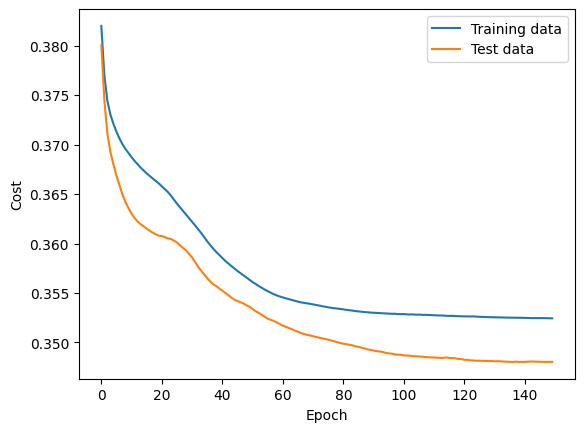

======== Stats for Train data ========
Winner accuracy: 20.23%
Place accuracy: 48.38%
======== Stats for Test data ========
Winner accuracy: 16.34%
Place accuracy: 40.08%


In [18]:
class TwelveFeaturesLambdaRank(nn.Module):
    def __init__(self):
        super(TwelveFeaturesLambdaRank, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(12, 4),
            nn.ReLU(),
            nn.Linear(4, 1)
        )

    def forward(self, x):
        return self.model(x)

    def optimizer(self):
        return optim.SGD(self.model.parameters(), lr=0.001, momentum=0.9)


def load_twelve_features(p):
    latest_horse_p = get_latest_horse_p(p)
    old_ps = get_old_ps(p)
    return np.array([
        p.rating,
        p.rating - latest_horse_p.rating if latest_horse_p.rating is not None else 25,
        count_number_of_previous_races(p),
        p.lane,
        p.number,
        p.horse_weight,
        p.horse_weight - latest_horse_p.horse_weight,
        p.gear_weight / (p.gear_weight + p.horse_weight),
        calculate_speed(latest_horse_p),
        calculate_mean_speed(old_ps),
        calculate_mean_decay_speed(p, old_ps),
        latest_horse_p.win_odds
    ], dtype=np.float32)


model = TwelveFeaturesLambdaRank()
_, _ = experiment_features(model, 12, load_twelve_features, distance=1400, epochs=150)

Loading races: 100%|██████████| 1321/1321 [02:21<00:00,  9.32it/s]


No nan: True


Loading races: 100%|██████████| 265/265 [00:32<00:00,  8.18it/s]


No nan: True
Training model on 1112 races.
Initial cost: 0.39205828914753826. CV cost: 0.39156499889589125
Epoch 10/100 - train cost = 0.36438, cv cost: 0.36204
Epoch 20/100 - train cost = 0.35965, cv cost: 0.35979
Epoch 30/100 - train cost = 0.35543, cv cost: 0.35552
Epoch 40/100 - train cost = 0.35274, cv cost: 0.35254
Epoch 50/100 - train cost = 0.35074, cv cost: 0.35121
Epoch 60/100 - train cost = 0.34964, cv cost: 0.35055
Epoch 70/100 - train cost = 0.34892, cv cost: 0.35043
Epoch 80/100 - train cost = 0.34838, cv cost: 0.35043
Epoch 90/100 - train cost = 0.34799, cv cost: 0.35068
Epoch 100/100 - train cost = 0.34774, cv cost: 0.35074


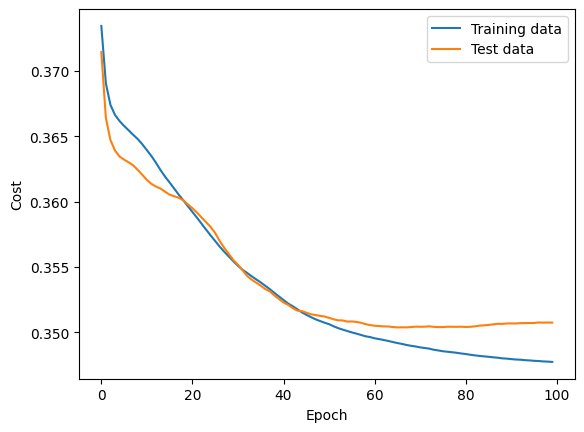

======== Stats for Train data ========
Winner accuracy: 22.65%
Place accuracy: 51.21%
======== Stats for Test data ========
Winner accuracy: 16.34%
Place accuracy: 40.47%


In [18]:
class SixteenFeaturesLambdaRank(nn.Module):
    def __init__(self):
        super(SixteenFeaturesLambdaRank, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(16, 4),
            nn.ReLU(),
            nn.Linear(4, 1)
        )

    def forward(self, x):
        return self.model(x)

    def optimizer(self):
        return optim.SGD(self.model.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)


def load_sixteen_features(p):
    latest_horse_p = get_latest_horse_p(p)
    latest_jockey_p = get_latest_jockey_p(p)
    old_horse_ps = get_old_ps(p)
    old_jockey_ps = get_old_jockey_ps(p)
    return np.array([
        p.rating,
        p.rating - latest_horse_p.rating if latest_horse_p.rating is not None else 25,
        len(old_horse_ps),
        p.lane,
        p.number,
        p.horse_weight,
        p.horse_weight - latest_horse_p.horse_weight,
        p.gear_weight / (p.gear_weight + p.horse_weight),
        calculate_speed(latest_horse_p),
        calculate_speed(latest_jockey_p),
        calculate_mean_speed(old_horse_ps),
        calculate_mean_speed(old_jockey_ps),
        calculate_mean_decay_speed(p, old_horse_ps),
        calculate_mean_decay_speed(p, old_jockey_ps),
        1 / latest_horse_p.win_odds,
        1 / latest_jockey_p.win_odds
    ], dtype=np.float32)


model = SixteenFeaturesLambdaRank()
_, _ = experiment_features(model, 16, load_sixteen_features, distance=1400, epochs=100)

Loading races: 100%|██████████| 1321/1321 [02:44<00:00,  8.04it/s]


No nan: True


Loading races: 100%|██████████| 265/265 [00:39<00:00,  6.63it/s]


No nan: True
Training model on 1112 races.
Initial cost: 0.39081175362677884. CV cost: 0.3902128898809033
Epoch 10/100 - train cost = 0.35695, cv cost: 0.35595
Epoch 20/100 - train cost = 0.35217, cv cost: 0.35078
Epoch 30/100 - train cost = 0.35020, cv cost: 0.34930
Epoch 40/100 - train cost = 0.34886, cv cost: 0.34895
Epoch 50/100 - train cost = 0.34777, cv cost: 0.34784
Epoch 60/100 - train cost = 0.34689, cv cost: 0.34745
Epoch 70/100 - train cost = 0.34616, cv cost: 0.34665
Epoch 80/100 - train cost = 0.34580, cv cost: 0.34622
Epoch 90/100 - train cost = 0.34559, cv cost: 0.34594
Epoch 100/100 - train cost = 0.34527, cv cost: 0.34550


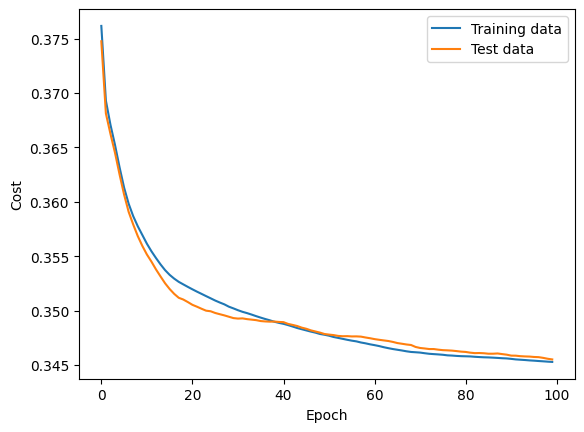

======== Stats for Train data ========
Winner accuracy: 23.38%
Place accuracy: 51.62%
Q Place accuracy: 18.12%
======== Stats for Test data ========
Winner accuracy: 20.62%
Place accuracy: 42.80%
Q Place accuracy: 14.79%


In [28]:
class TwentyFeaturesLambdaRank(nn.Module):
    def __init__(self):
        super(TwentyFeaturesLambdaRank, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(20, 4),
            nn.ReLU(),
            nn.Linear(4, 1)
        )

    def forward(self, x):
        return self.model(x)

    def optimizer(self):
        return optim.SGD(self.model.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)


def load_twenty_features(p):
    latest_horse_p = get_latest_horse_p(p)
    latest_jockey_p = get_latest_jockey_p(p)
    old_horse_ps = get_old_ps(p)
    old_jockey_ps = get_old_jockey_ps(p)
    return np.array([
        p.rating,
        p.rating - latest_horse_p.rating if latest_horse_p.rating is not None else 25,
        len(old_horse_ps),
        p.lane,
        p.number,
        p.horse_weight,
        p.horse_weight - latest_horse_p.horse_weight,
        p.gear_weight / (p.gear_weight + p.horse_weight),
        calculate_speed(latest_horse_p),
        calculate_speed(latest_jockey_p),
        calculate_mean_speed(old_horse_ps),
        calculate_mean_speed(old_jockey_ps),
        calculate_weighted_mean_speed(p, old_horse_ps),
        calculate_weighted_mean_speed(p, old_jockey_ps),
        calculate_mean_decay_speed(p, old_horse_ps),
        calculate_mean_decay_speed(p, old_jockey_ps),
        1 / latest_horse_p.win_odds,
        1 / latest_jockey_p.win_odds,
        1 / np.mean([x.win_odds for x in old_horse_ps]),
        np.mean([x.rating if x.rating is not None else 25 for x in old_horse_ps])
    ], dtype=np.float32)


model = TwentyFeaturesLambdaRank()
_, _ = experiment_features(model, 20, load_twenty_features, distance=1400, epochs=100)

In [18]:
def load_twenty_four_features(p):
    latest_horse_p = get_latest_horse_p(p)
    latest_jockey_p = get_latest_jockey_p(p)
    old_horse_ps = get_old_ps(p)
    old_jockey_ps = get_old_jockey_ps(p)
    old_trainer_ps = get_old_trainer_ps(p)
    return np.array([
        p.rating,
        p.rating - latest_horse_p.rating if latest_horse_p.rating is not None else 25,
        len(old_horse_ps),
        len(old_jockey_ps),
        p.lane,
        p.number,
        p.horse_weight,
        p.horse_weight - latest_horse_p.horse_weight,
        p.gear_weight / (p.gear_weight + p.horse_weight),
        calculate_speed(latest_horse_p),
        calculate_speed(latest_jockey_p),
        calculate_mean_speed(old_horse_ps),
        calculate_mean_speed(old_jockey_ps),
        calculate_mean_speed(old_trainer_ps),
        calculate_weighted_mean_speed(p, old_horse_ps),
        calculate_weighted_mean_speed(p, old_jockey_ps),
        calculate_mean_decay_speed(p, old_horse_ps),
        calculate_mean_decay_speed(p, old_jockey_ps),
        1 / latest_horse_p.win_odds,
        1 / latest_jockey_p.win_odds,
        1 / np.mean([x.win_odds for x in old_horse_ps]),
        1 / np.mean([x.win_odds for x in old_jockey_ps]),
        np.mean([x.rating if x.rating is not None else 25 for x in old_horse_ps]),
        np.mean([x.rating if x.rating is not None else 25 for x in old_trainer_ps])
    ], dtype=np.float32)


features_size = 24
f = load_twenty_four_features
tf_data_x, tf_data_y, tf_horse_nums, tf_winner_horses, tf_place_horses = load_data(features_size, f, distance=1400, train_mode=True)
tf_test_data, _, tf_test_h_nums, tf_test_winner_horses, tf_test_place_horses = load_data(features_size, f, distance=1400, train_mode=False)


Loading races: 100%|██████████| 1321/1321 [04:58<00:00,  4.42it/s]


No nan: True


Loading races: 100%|██████████| 265/265 [01:12<00:00,  3.67it/s]

No nan: True


In [24]:
class TwentyFourFeaturesLambdaRank(nn.Module):
    def __init__(self):
        super(TwentyFourFeaturesLambdaRank, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(24, 5),
            nn.ReLU(),
            nn.Linear(5, 1)
        )

    def forward(self, x):
        return self.model(x)

    def optimizer(self):
        return optim.SGD(self.model.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)


tf_model = TwentyFourFeaturesLambdaRank()
tf_data = group_data(tf_data_x, tf_data_y, tf_test_data, tf_horse_nums, tf_test_h_nums)
tf_results = group_results(tf_winner_horses, tf_place_horses, tf_test_winner_horses, tf_test_place_horses)
_ = experiment_features(model, 24, tf_data, tf_results, epochs=60, is_lambda_rank=True)

(14, 24)
Training model on 1112 races.


RuntimeError: mat1 and mat2 shapes cannot be multiplied (13x24 and 8x6)

In [18]:
def load_thirty_two_features(p):
    latest_horse_p = get_latest_horse_p(p)
    latest_jockey_p = get_latest_jockey_p(p)
    old_horse_ps = get_old_ps(p)
    old_jockey_ps = get_old_jockey_ps(p)
    old_trainer_ps = get_old_trainer_ps(p)
    horse_beaten_time = [get_beaten_time(x) for x in old_horse_ps]
    jockey_beaten_time = [get_beaten_time(x) for x in old_jockey_ps]
    return np.array([
        p.rating,
        p.rating - latest_horse_p.rating if latest_horse_p.rating is not None else 25,
        len(old_horse_ps),
        len(old_jockey_ps),
        p.lane,
        p.number,
        p.horse_weight,
        p.horse_weight - latest_horse_p.horse_weight,
        p.gear_weight / (p.gear_weight + p.horse_weight),
        calculate_speed(latest_horse_p),
        calculate_speed(latest_jockey_p),
        calculate_mean_speed(old_horse_ps),
        calculate_mean_speed(old_jockey_ps),
        calculate_mean_speed(old_trainer_ps),
        calculate_std_speed(old_horse_ps),
        calculate_std_speed(old_jockey_ps),
        get_maximum_speed(old_horse_ps),
        get_maximum_speed(old_jockey_ps),
        calculate_weighted_mean_speed(p, old_horse_ps),
        calculate_weighted_mean_speed(p, old_jockey_ps),
        calculate_mean_decay_speed(p, old_horse_ps),
        calculate_mean_decay_speed(p, old_jockey_ps),
        1 / latest_horse_p.win_odds,
        1 / latest_jockey_p.win_odds,
        1 / np.mean([x.win_odds for x in old_horse_ps]),
        1 / np.mean([x.win_odds for x in old_jockey_ps]),
        np.mean([x.rating if x.rating is not None else 25 for x in old_horse_ps]),
        np.mean([x.rating if x.rating is not None else 25 for x in old_trainer_ps]),
        np.mean(horse_beaten_time),
        np.mean(jockey_beaten_time),
        np.std(horse_beaten_time),
        np.std(jockey_beaten_time),
    ], dtype=np.float32)


features_size = 32
f = load_thirty_two_features
tt_data_x, tt_data_y, tt_horse_nums, tt_winner_horses, tt_place_horses = load_data(features_size, f, distance=1400, train_mode=True)
tt_test_data, _, tt_test_h_nums, tt_test_winner_horses, tt_test_place_horses = load_data(features_size, f, distance=1400, train_mode=False)

Loading races:   0%|          | 0/1321 [00:00<?, ?it/s]Error closing cursor
Traceback (most recent call last):
  File "/home/andytam321/anaconda3/envs/JockeyClub/lib/python3.12/site-packages/sqlalchemy/engine/result.py", line 2270, in _fetchall_impl
    return list(self.iterator)
           ^^^^^^^^^^^^^^^^^^^
  File "/home/andytam321/anaconda3/envs/JockeyClub/lib/python3.12/site-packages/sqlalchemy/orm/loading.py", line 219, in chunks
    fetch = cursor._raw_all_rows()
            ^^^^^^^^^^^^^^^^^^^^^^
  File "/home/andytam321/anaconda3/envs/JockeyClub/lib/python3.12/site-packages/sqlalchemy/engine/result.py", line 540, in _raw_all_rows
    rows = self._fetchall_impl()
           ^^^^^^^^^^^^^^^^^^^^^
  File "/home/andytam321/anaconda3/envs/JockeyClub/lib/python3.12/site-packages/sqlalchemy/engine/cursor.py", line 2135, in _fetchall_impl
    return self.cursor_strategy.fetchall(self, self.cursor)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/andytam321/ana

KeyboardInterrupt: 

Training model on 1112 races.
Initial cost: 0.37411281383402056. CV cost: 0.3746231705431015
Epoch 10/150 - train cost = 0.34590, cv cost: 0.34634, train accuracy: 25.24%
Epoch 20/150 - train cost = 0.34145, cv cost: 0.34205, train accuracy: 24.60%
Epoch 30/150 - train cost = 0.33746, cv cost: 0.33817, train accuracy: 24.76%
Epoch 40/150 - train cost = 0.33394, cv cost: 0.33447, train accuracy: 25.40%
Epoch 50/150 - train cost = 0.33088, cv cost: 0.33111, train accuracy: 25.16%
Epoch 60/150 - train cost = 0.32849, cv cost: 0.32829, train accuracy: 25.00%
Epoch 70/150 - train cost = 0.32687, cv cost: 0.32656, train accuracy: 25.08%
Epoch 80/150 - train cost = 0.32579, cv cost: 0.32535, train accuracy: 25.08%
Epoch 90/150 - train cost = 0.32505, cv cost: 0.32461, train accuracy: 24.92%
Epoch 100/150 - train cost = 0.32451, cv cost: 0.32422, train accuracy: 25.16%
Epoch 110/150 - train cost = 0.32414, cv cost: 0.32403, train accuracy: 25.24%
Epoch 120/150 - train cost = 0.32384, cv cost: 

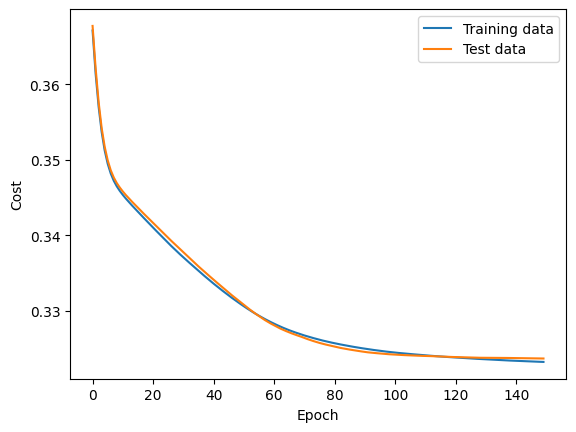

======== Stats for Train data ========
Winner accuracy: 25.16%
Place accuracy: 54.05%
Q Place accuracy: 21.60%
======== Stats for Test data ========
Winner accuracy: 22.18%
Place accuracy: 47.47%
Q Place accuracy: 19.07%
======== Overall stats ========
Max test WIN accuracy: 23.74%
Train accuracy then: 25.24%


In [61]:
class ThirtyTwoFeaturesLambdaRank(nn.Module):
    def __init__(self):
        super(ThirtyTwoFeaturesLambdaRank, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(32, 4),
            nn.ReLU(),
            nn.Linear(4, 1),
        )

    def forward(self, x):
        return self.model(x)

    def optimizer(self):
        return optim.SGD(self.model.parameters(), lr=0.0001, momentum=0.9)


model = ThirtyTwoFeaturesLambdaRank()
tt_data = group_data(tt_data_x, tt_data_y, tt_test_data, tt_horse_nums, tt_test_h_nums)
tt_results = group_results(tt_winner_horses, tt_place_horses, tt_test_winner_horses, tt_test_place_horses)
_ = experiment_features(model, 32, tt_data, tt_results, epochs=150, is_lambda_rank=True)

In [ ]:
def load_forty_eight_features(p):
    race_mean_rating, race_std_rating = get_average_rating(p.race)
    race_max_rating = get_max_rating(p.race)
    race_min_rating = get_min_rating(p.race)
    old_horse_ps = get_old_ps(p)
    old_jockey_ps = get_old_jockey_ps(p)
    old_trainer_ps = get_old_trainer_ps(p)
    previous_horse_race = old_horse_ps[-1]
    previous_jockey_race = old_jockey_ps[-1]

    weighted_rating_diffs = get_rating_diff(p, old_horse_ps)
    print(f"calculating weighted ranking rate: {len(old_horse_ps)}, {len(old_jockey_ps)}, {len(old_trainer_ps)}")
    horse_weights, horse_weighted_ranking = get_weighted_ranking_rate(p, old_horse_ps)
    jockey_weights, jockey_weighted_ranking = get_weighted_ranking_rate(p, old_jockey_ps)
    print("calculating trainer")
    trainer_weights, trainer_weighted_ranking = get_weighted_ranking_rate(p, old_trainer_ps)

    print("begin")
    part_one = np.array([
        # independent p features (6)
        p.rating,
        p.number,
        p.lane,
        p.horse_weight,
        p.gear_weight,
        p.gear_weight / (p.gear_weight + p.horse_weight),

        # race dependent features (6)
        p.rating - race_mean_rating,
        (p.rating - race_mean_rating) / race_std_rating,
        race_max_rating - p.rating,
        p.rating - race_min_rating,
        p.lane / get_number_of_participants(p.race),
        p.number / get_number_of_participants(p.race),
    ])
    print("finished part one")
    part_two = np.array([
        # horse historic features (16)
        len(old_horse_ps),
        get_ranking_from_participation(previous_horse_race),
        calculate_speed(previous_horse_race),
        get_maximum_speed(old_horse_ps),
        get_beaten_time(previous_horse_race),
        calculate_mean_speed(old_horse_ps),
        calculate_std_speed(old_horse_ps),
        calculate_weighted_mean_speed(p, old_horse_ps),
        calculate_mean_decay_speed(p, old_horse_ps),
        previous_horse_race.win_odds,
        p.rating - previous_horse_race.rating,
        calculate_weighted_ranking(horse_weights, horse_weighted_ranking, mode=WIN),    # weighted win rate
        calculate_weighted_ranking(horse_weights, horse_weighted_ranking, mode=PLACE),  # weighted place rate
        calculate_weighted_ranking(horse_weights, horse_weighted_ranking),              # weighted mean rank
        np.mean(weighted_rating_diffs),
        np.std(weighted_rating_diffs),

        # jockey historic features (12)
        len(old_jockey_ps),
        get_ranking_from_participation(previous_jockey_race),
        calculate_speed(previous_jockey_race),
        get_maximum_speed(old_jockey_ps),
        get_beaten_time(previous_jockey_race),
        calculate_mean_speed(old_jockey_ps),
        calculate_weighted_mean_speed(p, old_jockey_ps),
        calculate_mean_decay_speed(p, old_jockey_ps),
        previous_jockey_race.win_odds,
        calculate_weighted_ranking(jockey_weights, jockey_weighted_ranking, mode=WIN),    # weighted win rate
        calculate_weighted_ranking(jockey_weights, jockey_weighted_ranking, mode=PLACE),  # weighted place rate
        calculate_weighted_ranking(jockey_weights, jockey_weighted_ranking),              # weighted mean rank
    ])
    print("finished part two")
    part_three = np.array([
        # trainer historic features (8)
        len(p.horse.trainer.horses),
        calculate_mean_speed(old_trainer_ps),
        calculate_weighted_mean_speed(p, old_trainer_ps),
        calculate_mean_decay_speed(p, old_trainer_ps),
        get_mean_rating(old_trainer_ps),
        calculate_weighted_ranking(trainer_weights, trainer_weighted_ranking, mode=WIN),    # weighted win rate
        calculate_weighted_ranking(trainer_weights, trainer_weighted_ranking, mode=PLACE),  # weighted place rate
        calculate_weighted_ranking(trainer_weights, trainer_weighted_ranking),              # weighted mean rank
    ], dtype=np.float32)
    print("finished part three")

    result = np.zeros(48, dtype=np.float32)
    result[:12] = part_one
    result[12:40] = part_two
    result[40:48] = part_three
    return result


features_size = 48
f = load_forty_eight_features
fe_data_x, fe_data_y, fe_horse_nums, fe_winner_horses, fe_place_horses = load_data(features_size, f, distance=1400, train_mode=True)
fe_test_data, _, fe_test_h_nums, fe_test_winner_horses, fe_test_place_horses = load_data(features_size, f, distance=1400, train_mode=False)

Loading races:   0%|          | 0/1321 [00:00<?, ?it/s]

calculating weighted ranking rate: 14, 743, 3833
calculating trainer


/home/andytam321/anaconda3/envs/JockeyClub/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/andytam321/anaconda3/envs/JockeyClub/lib/python3.12/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


begin
finished part one
finished part two
finished part three
calculating weighted ranking rate: 6, 4332, 3530


In [19]:
def convert_top_3_to_win_place(top_3_numbers):
    win_horses_all = {}
    place_horses_all = {}
    for race_id in top_3_numbers:
        place_horses = top_3_numbers[race_id]
        win_horses = top_3_numbers[race_id][:1]
        win_horses_all[race_id] = win_horses
        place_horses_all[race_id] = place_horses

    return win_horses_all, place_horses_all


In [96]:
def perform_bets(model, normalized_x, horse_nums, f_threshold, s_threshold):
    model.eval()
    with torch.no_grad():
        predictions = model(normalized_x).flatten()
        predictions = torch.softmax(predictions, dim=0)
    horse_nums = horse_nums.tolist()
    horse_predictions = list(zip(horse_nums, predictions.tolist()))
    horse_predictions.sort(key=lambda x: x[1], reverse=True)

    winner = horse_predictions[0]
    runner_up = horse_predictions[1]
    fourth = horse_predictions[3]

    bets = []
    if winner[1] - runner_up[1] >= f_threshold:
        bets.append((WIN, winner[0]))
    if winner[1] - fourth[1] >= s_threshold:
        bets.append((PLACE, winner[0]))
    if runner_up[1] - fourth[1] >= s_threshold:
        bets.append((Q_PLACE, (winner[0], runner_up[0])))

    return bets

def evaluate_accuracy(model, test_data, test_horse_nums, test_top_3, train_mean, train_std, f_threshold, s_threshold):
    total_count = {WIN: 0, PLACE: 0, Q_PLACE: 0}
    profit_count = {WIN: 0, PLACE: 0, Q_PLACE: 0}
    correct_count = {WIN: 0, PLACE: 0, Q_PLACE: 0}
    for race_id in tqdm(test_data, desc="Simulating races"):
        x = test_data[race_id]
        x = torch.tensor(x, dtype=torch.float32, device="cuda")
        normalized_x = (x - train_mean) / train_std

        bets = perform_bets(model, normalized_x, test_horse_nums[race_id], f_threshold, s_threshold)
        this_top_3 = test_top_3[race_id].tolist()
        for pool, bet in bets:
            total_count[pool] += 1
            profit_count[pool] -= 10
            if pool == WIN:
                if this_top_3[0] == bet:
                    win_odds = session.query(Winnings).filter(Winnings.race_id == race_id).filter(Winnings.pool == pool).one()
                    correct_count[pool] += 1
                    profit_count[pool] += win_odds.amount
            elif pool == PLACE:
                if bet in this_top_3:
                    try:
                        win_odds = session.query(Winnings).filter(Winnings.race_id == race_id).filter(Winnings.pool == pool).filter(Winnings.combination == bet).one()
                    except Exception:
                        # incorrect
                        continue
                    correct_count[pool] += 1
                    profit_count[pool] += win_odds.amount
            elif pool == Q_PLACE:
                fst, snd = bet
                if fst in this_top_3 and snd in this_top_3:
                    all_odds = session.query(Winnings).filter(Winnings.race_id == race_id).filter(Winnings.pool == pool).all()
                    win_odds = None
                    for odds in all_odds:
                        if f"{fst},{snd}" == odds.combination or f"{snd},{fst}" == odds.combination:
                            win_odds = odds
                    if win_odds is None:
                        profit_count[pool] += 10
                        total_count[pool] -= 1
                    else:
                        profit_count[pool] += win_odds.amount
                        correct_count[pool] += 1
    return correct_count, profit_count, total_count


In [29]:
directory = "data2"

data_x = np.load(f"{directory}/data_x.npz")
data_y = np.load(f"{directory}/data_y.npz")
horse_nums = np.load(f"{directory}/horse_nums.npz")
top_3 = np.load(f"{directory}/top_3.npz")

test_data_x = np.load(f"{directory}/test_data_x.npz")
test_horse_nums = np.load(f"{directory}/test_horse_nums.npz")
test_top_3 = np.load(f"{directory}/test_top_3.npz")

final_data_x = np.load(f"{directory}/final_data_x.npz")
final_horse_nums = np.load(f"{directory}/final_horse_nums.npz")
final_top_3 = np.load(f"{directory}/final_top_3.npz")

train_winner_horses, train_place_horses  = convert_top_3_to_win_place(top_3)
test_winner_horses, test_place_horses = convert_top_3_to_win_place(test_top_3)

In [128]:
class LambdaRank48(nn.Module):
    def __init__(self):
        super(LambdaRank48, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(42, 5),
            nn.ReLU(),
            nn.Linear(5, 1),
        )

    def forward(self, x):
        return self.model(x)

    def optimizer(self):
        return optim.SGD(self.model.parameters(), lr=0.001, momentum=0.9, weight_decay=0.0005)

Training model on 1112 races.
Initial cost: 0.3631560321924069. CV cost: 0.36564295426491766
Epoch 10/100 - train cost = 0.31937, cv cost: 0.32401, train accuracy: 25.89%
Epoch 20/100 - train cost = 0.31753, cv cost: 0.32410, train accuracy: 26.05%
Epoch 30/100 - train cost = 0.31648, cv cost: 0.32451, train accuracy: 26.78%
Epoch 40/100 - train cost = 0.31587, cv cost: 0.32485, train accuracy: 27.27%
Epoch 50/100 - train cost = 0.31551, cv cost: 0.32523, train accuracy: 27.02%
Epoch 60/100 - train cost = 0.31511, cv cost: 0.32596, train accuracy: 27.59%
Epoch 70/100 - train cost = 0.31473, cv cost: 0.32635, train accuracy: 27.59%
Epoch 80/100 - train cost = 0.31436, cv cost: 0.32679, train accuracy: 27.10%
Epoch 90/100 - train cost = 0.31403, cv cost: 0.32686, train accuracy: 27.18%
Epoch 100/100 - train cost = 0.31387, cv cost: 0.32683, train accuracy: 27.27%


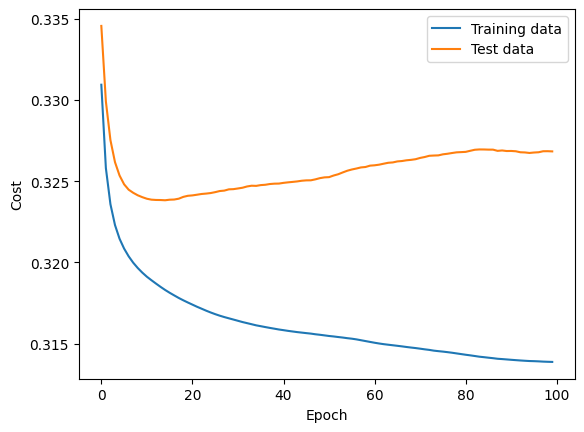

======== Stats for Train data ========
Winner accuracy: 27.27%
Place accuracy: 56.80%
Q Place accuracy: 22.57%
======== Stats for Test data ========
Winner accuracy: 25.68%
Place accuracy: 53.31%
Q Place accuracy: 19.07%
======== Overall stats ========
Max test WIN accuracy: 28.02%
Train accuracy then: 26.13%


In [129]:
model = LambdaRank48()
fe_data = group_data(data_x, data_y, test_data_x, horse_nums, test_horse_nums)
fe_results = group_results(train_winner_horses, train_place_horses, test_winner_horses, test_place_horses)
# _ = experiment_features(model, 48, fe_data, fe_results, is_lambda_rank=True, epochs=100)
# print("\n=" * 100)
model_2 = LambdaRank48()
_, _, train_mean, train_std = experiment_features(model_2, 42, fe_data, fe_results, is_lambda_rank=True, epochs=100)

In [ ]:
model = LambdaRank48()
_, _, a_train_mean, a_train_std = experiment_features(model, 48, fe_data, fe_results, is_lambda_rank=True, epochs=100)

In [132]:
test_model = model_2
c_count, p_count, t_count = evaluate_accuracy(test_model, test_data_x, test_horse_nums, test_top_3, train_mean, train_std, f_threshold=0.1, s_threshold=0.03)
print(f"Total number of races: {len(test_data_x)}")
for pool in c_count:
    profit = p_count[pool]
    proportion = t_count[pool] / len(test_data_x)
    if t_count[pool] == 0:
        accuracy = 0
    else:
        accuracy = c_count[pool] / t_count[pool]
    print(f"{pool}: accuracy = {accuracy * 100:.2f}%, proportion = {proportion * 100:.2f}%, profit = {profit}")

Simulating races: 100%|██████████| 257/257 [00:00<00:00, 2121.41it/s]

Total number of races: 257
WIN: accuracy = 47.06%, proportion = 6.61%, profit = -8.50
PLACE: accuracy = 50.23%, proportion = 82.88%, profit = -466.70
QUINELLA PLACE: accuracy = 26.21%, proportion = 40.08%, profit = 214.50


In [124]:
test_model = model.to("cuda")
c_count, p_count, t_count = evaluate_accuracy(test_model, test_data_x, test_horse_nums, test_top_3, a_train_mean, a_train_std, f_threshold=0, s_threshold=0)

for pool in c_count:
    profit = p_count[pool]
    proportion = t_count[pool] / len(test_data_x)
    if t_count[pool] == 0:
        accuracy = 0
    else:
        accuracy = c_count[pool] / t_count[pool]
    print(f"{pool}: accuracy = {accuracy * 100:.2f}%, proportion = {proportion * 100:.2f}%, profit = {profit}")

Simulating races: 100%|██████████| 257/257 [00:00<00:00, 3509.82it/s]

WIN: accuracy = 4.71%, proportion = 33.07%, profit = -714.50
PLACE: accuracy = 100.00%, proportion = 0.39%, profit = 1.00
QUINELLA PLACE: accuracy = 0.00%, proportion = 0.00%, profit = 0


In [138]:
xs = model_2.state_dict()

In [139]:
torch.save(xs, "data/model_state_dict.pth")

In [141]:
torch.save(train_mean, "data/train_mean.pth")
torch.save(train_std, "data/train_std.pth")

In [38]:
ys = torch.load("data/model_state_dict.pth", weights_only=True)
model_b = LambdaRank48()
model_b.load_state_dict(ys)
model_b = model_b.to("cuda")
train_mean_b = torch.load("data/train_mean.pth")
train_std_b = torch.load("data/train_std.pth")

c_count, p_count, t_count = evaluate_accuracy(model_b, test_data_x, test_horse_nums, test_top_3, train_mean_b, train_std_b, f_threshold=0.002, s_threshold=0.001)
for pool in c_count:
    profit = p_count[pool]
    proportion = t_count[pool] / len(test_data_x)
    if t_count[pool] == 0:
        accuracy = 0
    else:
        accuracy = c_count[pool] / t_count[pool]
    print(f"{pool}: accuracy = {accuracy * 100:.2f}%, proportion = {proportion * 100:.2f}%, profit = {profit}")


/tmp/ipykernel_18275/2985439391.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_mean_b = torch.load("data/train_mean.pth")
/tmp/ipykernel_18275/2985439391.py:6: Fu

WIN: accuracy = 25.81%, proportion = 60.31%, profit = -467.50
PLACE: accuracy = 50.59%, proportion = 99.22%, profit = -525.50
QUINELLA PLACE: accuracy = 23.53%, proportion = 85.99%, profit = 298.00
